# EN3160 Assignment 01

## Student Details

- **Name:** KPCP Keerawella
- **Index Number:** 230332B
- **GitHub Profile:** chalee88

## Introduction

This notebook contains the solutions for Assignment 01 on intensity transformations and neighborhood filtering.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

---

## Question 01 - Piecewise Linear Intensity Transformation

### Objective

- Implement `intensity_transform(im, breakpoints)`.
- Apply the transformation to the image in Fig. 1b.
- Show the transformation plot and original/transformed images side-by-side.

### Discussion

- Explain the selected breakpoints and their effect on the output image.

In [2]:
def intensity_transform(im, breakpoints):
    """
    Apply a piecewise linear intensity transformation to a grayscale image. 

    Parameters
    ----------
    im : np.ndarray
        Input grascale image with intensity values in [0, 255]

    breakpoints : np.ndarray
        Array of shape (N, 2) where each row is:
        [input_intensity, output_intensity]

    Returns 
    -------
    transformed : np.ndarray
        Transformed grayscale image.

    transform : np.ndarray
        Lookup table containing the output value for each input
        intesity from 0 to 255.
    """


    # Input and output coordinates of the breakpoints
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    # All possible input intensity values
    input_levels = np.arange(256)

    # Piecewise-linear interpolation between the breakpoints
    transform = np.interp(input_levels, x, y)

    # Make sure output intensities stay inside (0, 255)
    transform = np.clip(transform, 0, 255).astype(np.uint8)

    # Apply the lookup table to every pixel
    transformed = cv.LUT(im, transform)

    return transformed, transform


In [3]:
# load the image

im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

# breakpoints given in the assignment 

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

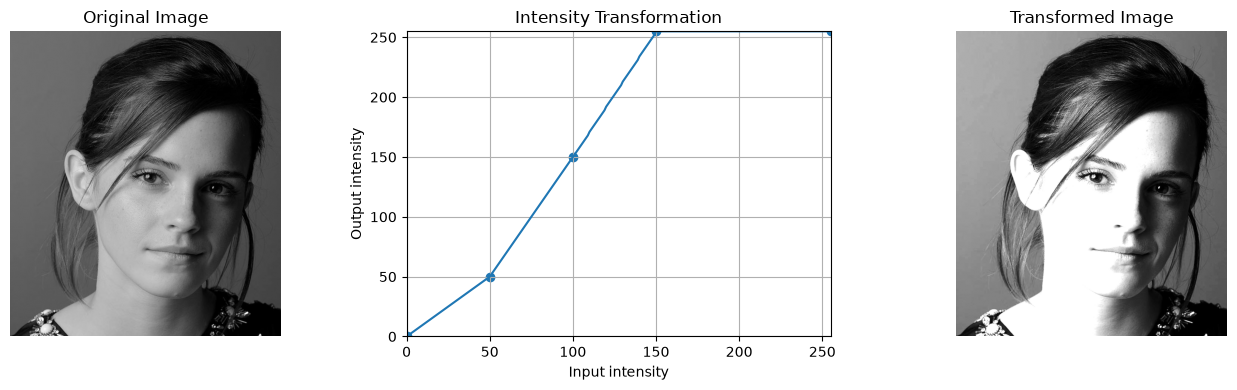

In [4]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
breakpoints = np.array([
    [0, 0],
    [50, 100],
    [100, 130],
    [150, 180],
    [255, 255]
], dtype=np.float32)

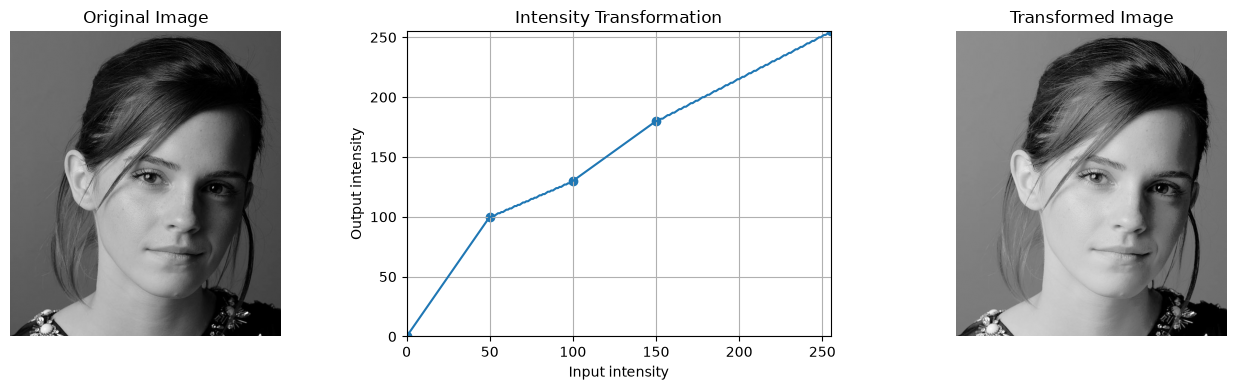

In [6]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
breakpoints = np.array([
    [0, 0],
    [50, 70],
    [100, 125],
    [150, 180],
    [255, 255]
], dtype=np.float32)

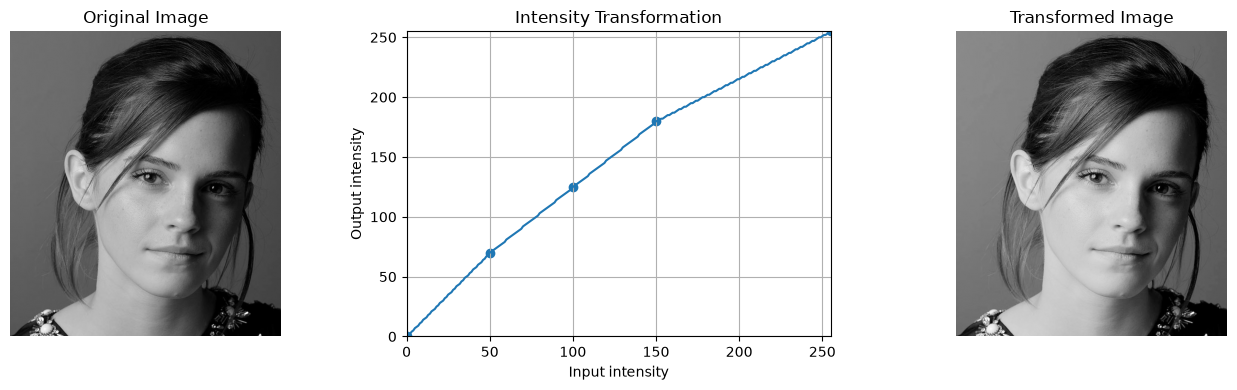

In [8]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

The initial given breakpoints caused intensities above 150 to map to 255, which resulted in substantial highlight saturation and loss of detail. The breakpoints were therefore adjusted to provide moderate expansion of the shadow and midtone ranges while compressing the higher intensity range. This preserved highlight information while improving the visibility of darker details. 

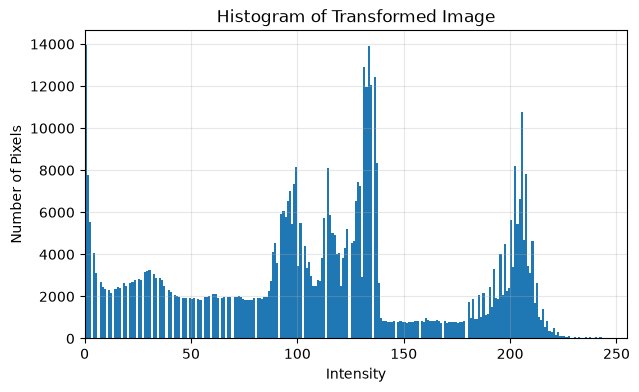

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(im_transformed.ravel(), bins=256, range=[0, 256])
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Transformed Image")
plt.xlim([0, 255])
plt.grid(alpha=0.3)
plt.show()

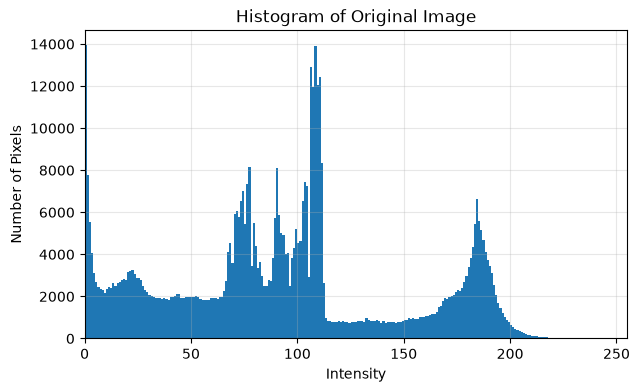

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(im.ravel(), bins=256, range=[0, 256])
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Original Image")
plt.xlim([0, 255])
plt.grid(alpha=0.3)
plt.show()

---

## Question 02 - Brain Proton Density Image Enhancement

### Objective

- Apply intensity transformations to accentuate white matter and gray matter separately.
- Show the transformation plots.

### Sections

- White matter enhancement
- Gray matter enhancement
- Comparison and interpretation

In [11]:
# Load brain proton-density image
brain = cv.imread("images/q2.jpeg",
                  cv.IMREAD_GRAYSCALE)

if brain is None:
    raise FileNotFoundError(
        "Brain image could not be loaded. Check the file path."
    )

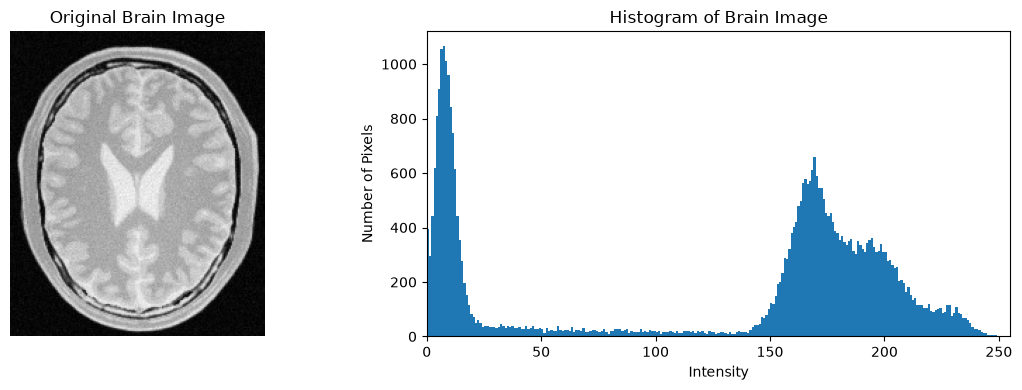

In [12]:
# Display original image and histogram 

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original Brain Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(
    brain.ravel(),
    bins=256,
    range=[0, 256]
)
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Brain Image")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

In [73]:
# White matter enhancement - 190 - 255

white_breakpoints = np.array([
    [0,   0],
    [150, 130],
    [180, 155],
    [220, 225],
    [255, 255]
], dtype=np.float32)

In [74]:
# Gray matter enhancement - 150 - 180 

gray_breakpoints = np.array([
    [0,   0],
    [120, 90],
    [150, 120],
    [180, 190],
    [220, 230],
    [255, 255]
], dtype=np.float32)

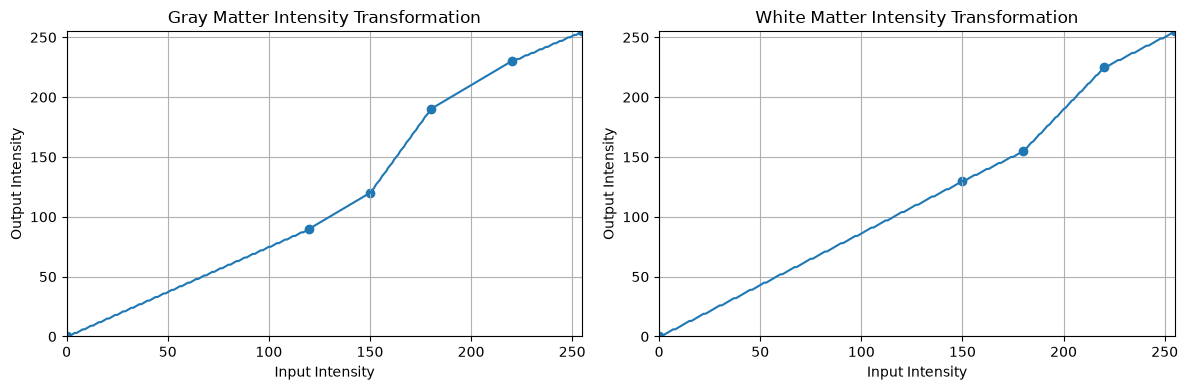

In [75]:
gray_enhanced, gray_transform = intensity_transform(
    brain,
    gray_breakpoints
)

white_enhanced, white_transform = intensity_transform(
    brain,
    white_breakpoints
)
# ------------------------------------------------------------
# 5. Plot transformations
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.arange(256), gray_transform)
plt.scatter(
    gray_breakpoints[:, 0],
    gray_breakpoints[:, 1]
)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Gray Matter Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(np.arange(256), white_transform)
plt.scatter(
    white_breakpoints[:, 0],
    white_breakpoints[:, 1]
)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("White Matter Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.tight_layout()
plt.show()

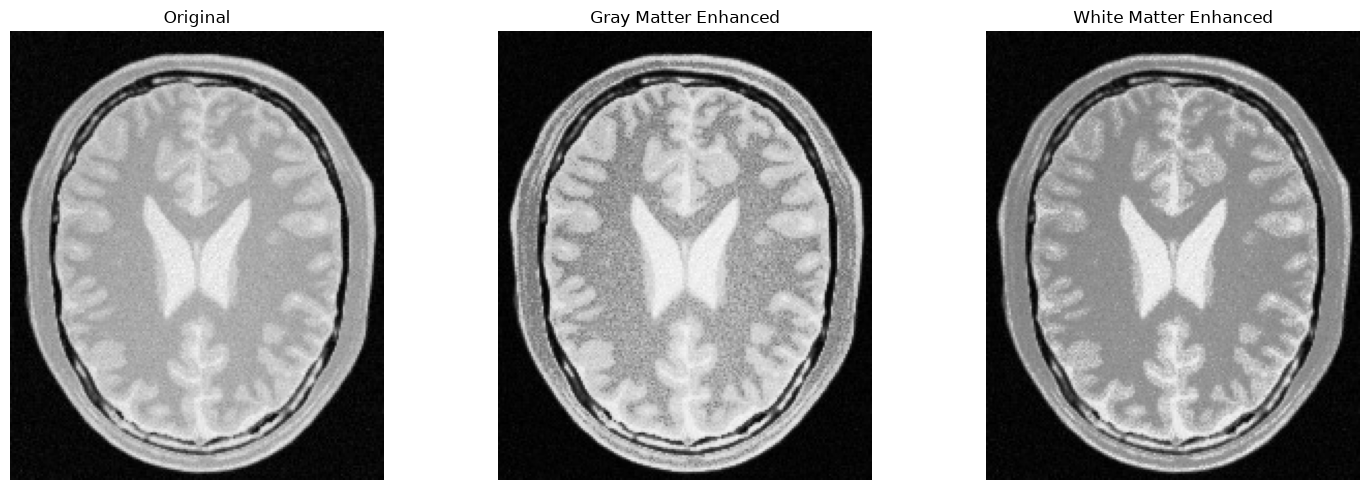

In [76]:
# ------------------------------------------------------------
# 6. Compare results
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Enhanced")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(white_enhanced, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
%matplotlib inline

In [64]:
def inspect_pixel(im, x, y):
    value = int(im[y, x])
    print(f"(x={x}, y={y}) -> intensity = {value}")
    return value

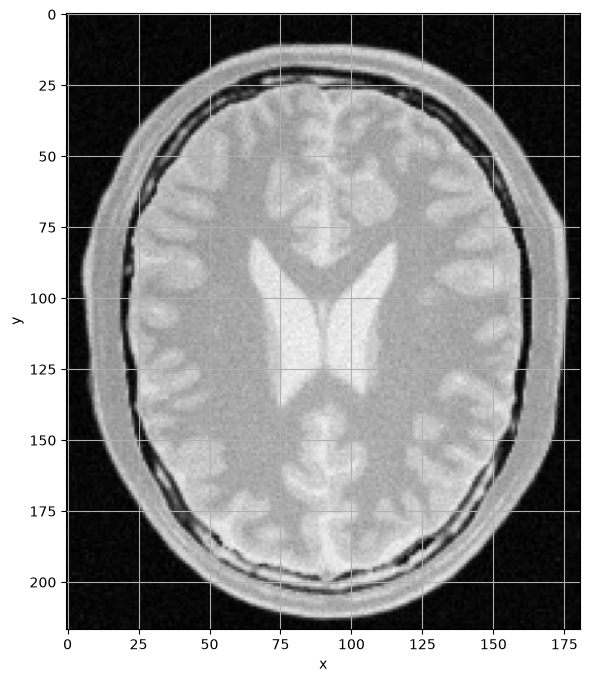

In [65]:
plt.figure(figsize=(8, 8))
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [66]:
gm_points = [
    (75, 175),
    (150, 100),
    (50, 125),
    (50, 100),
    (50, 75),
    (125, 75),
    (75, 150),
    (100, 175)
]

gm_values = []

for x, y in gm_points:
    val = inspect_pixel(brain, x, y)
    gm_values.append(val)

print("\nGray matter samples:", gm_values)
print("Mean:", np.mean(gm_values))
print("Median:", np.median(gm_values))
print("Min:", np.min(gm_values))
print("Max:", np.max(gm_values))

(x=75, y=175) -> intensity = 176
(x=150, y=100) -> intensity = 165
(x=50, y=125) -> intensity = 169
(x=50, y=100) -> intensity = 174
(x=50, y=75) -> intensity = 158
(x=125, y=75) -> intensity = 165
(x=75, y=150) -> intensity = 164
(x=100, y=175) -> intensity = 215

Gray matter samples: [176, 165, 169, 174, 158, 165, 164, 215]
Mean: 173.25
Median: 167.0
Min: 158
Max: 215


In [67]:
wm_points = [
    (100, 175),
    (125, 175),
    (150, 150),
    (50, 175),
    (25, 125),
    (150, 75),
    (50, 50),
    (25, 100)
]

wm_values = []

for x, y in wm_points:
    val = inspect_pixel(brain, x, y)
    wm_values.append(val)

print("\nWhite matter samples:", wm_values)
print("Mean:", np.mean(wm_values))
print("Median:", np.median(wm_values))
print("Min:", np.min(wm_values))
print("Max:", np.max(wm_values))

(x=100, y=175) -> intensity = 215
(x=125, y=175) -> intensity = 199
(x=150, y=150) -> intensity = 224
(x=50, y=175) -> intensity = 193
(x=25, y=125) -> intensity = 181
(x=150, y=75) -> intensity = 204
(x=50, y=50) -> intensity = 181
(x=25, y=100) -> intensity = 182

White matter samples: [215, 199, 224, 193, 181, 204, 181, 182]
Mean: 197.375
Median: 196.0
Min: 181
Max: 224


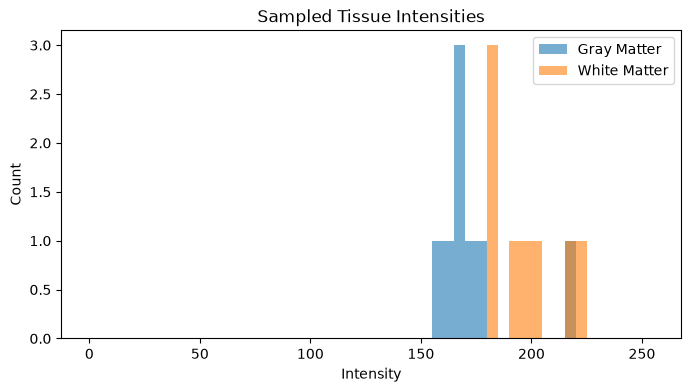

In [68]:
plt.figure(figsize=(8, 4))

plt.hist(
    gm_values,
    bins=np.arange(0, 257, 5),
    alpha=0.6,
    label="Gray Matter"
)

plt.hist(
    wm_values,
    bins=np.arange(0, 257, 5),
    alpha=0.6,
    label="White Matter"
)

plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title("Sampled Tissue Intensities")
plt.legend()
plt.show()

### Q2 – Gray Matter and White Matter Enhancement

The image histogram and sampled tissue intensities suggested approximate ranges of **150–180 for gray matter** and **180–220 for white matter**.

To enhance each tissue range, separate piecewise-linear intensity transformations were designed with a steeper slope over the corresponding interval. A steeper slope increases contrast by spreading a narrow input intensity range over a wider output range.

For gray matter, the range 150–180 was strongly expanded. For white matter, the range 180–220 was moderately expanded while preserving the rest of the image more naturally.

These transformations enhance the **intensity ranges associated with the tissues**, not the anatomical regions themselves, because the operation depends only on pixel intensity.

---

## Question 03 - Gamma Correction in L*a*b* Color Space

### Objective

- Apply gamma correction to the `L` plane in `L*a*b*` color space.
- State the selected gamma value.
- Show histograms of original and corrected images.

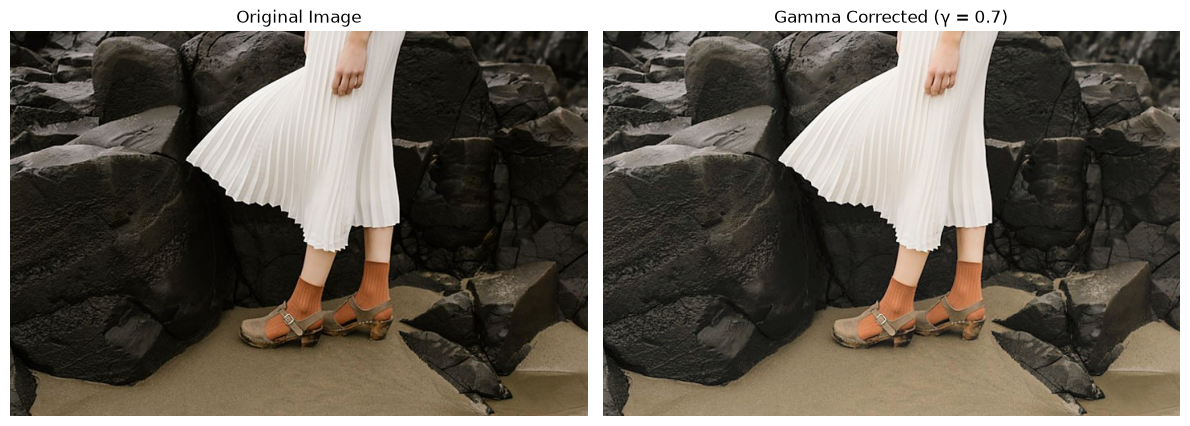

In [77]:
# Load image
img = cv.imread("images/q3.jpeg")

if img is None:
    raise FileNotFoundError("Check the image path.")

# Convert for display
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert BGR -> Lab
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

# Split channels
L, a, b = cv.split(lab)

# -----------------------------
# Gamma correction on L channel
# -----------------------------

gamma = 0.7

# Normalize L to [0, 1]
L_norm = L / 255.0

# Apply gamma
L_corrected = np.power(L_norm, gamma)

# Convert back to [0, 255]
L_corrected = np.clip(L_corrected * 255, 0, 255).astype(np.uint8)

# Merge corrected L with original a and b
lab_corrected = cv.merge([L_corrected, a, b])

# Convert Lab -> BGR -> RGB
corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
corrected_rgb = cv.cvtColor(corrected_bgr, cv.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected_rgb)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

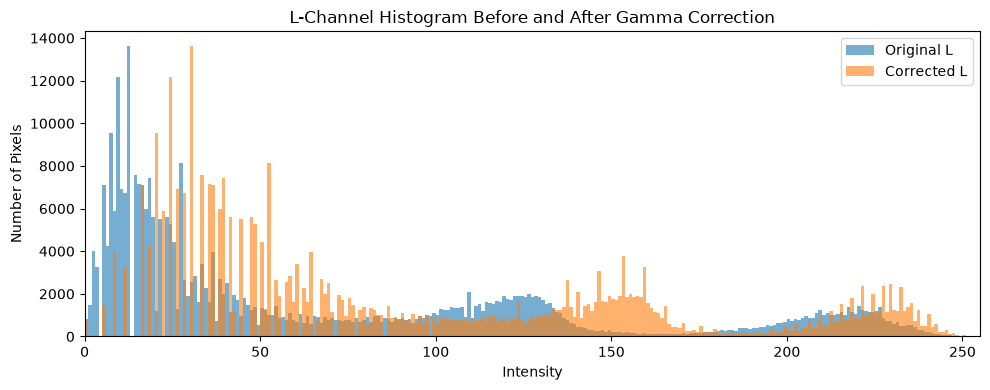

In [79]:
plt.figure(figsize=(10, 4))

plt.hist(
    L.ravel(),
    bins=256,
    range=[0, 256],
    alpha=0.6,
    label="Original L"
)

plt.hist(
    L_corrected.ravel(),
    bins=256,
    range=[0, 256],
    alpha=0.6,
    label="Corrected L"
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("L-Channel Histogram Before and After Gamma Correction")
plt.legend()
plt.xlim([0, 255])

plt.tight_layout()
plt.show()



Gamma correction was applied only to the **L (lightness) channel** of the L*a*b* image using **γ = 0.7**. Since γ < 1, lower and mid-range lightness values were increased, revealing more detail in the darker regions while largely preserving the color information.

The corrected L-channel histogram shifts toward higher intensities, confirming the increase in lightness.

---

## Question 04 - Vibrance Enhancement Using Saturation Transformation

### Objective

- Split the image into hue, saturation, and value planes.
- Apply the vibrance transformation to the saturation plane.
- Adjust `a` and report the selected value.
- Display the original image, enhanced image, and transformation.

### Parameters

- `sigma = 70`
- `a = `

In [80]:
# Load image
img = cv.imread("images/q4.jpeg")

if img is None:
    raise FileNotFoundError("Check the image path.")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert BGR -> HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)


In [81]:
# Vibrance transformation
# ------------------------------------------------------------

a = 0.5
sigma = 70

x = np.arange(256, dtype=np.float32)

transform = (
    x
    + a * 128 *
    np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
)

transform = np.minimum(transform, 255).astype(np.uint8)

# Apply LUT to saturation channel
S_enhanced = cv.LUT(S, transform)

# Recombine HSV
hsv_enhanced = cv.merge([H, S_enhanced, V])

# Convert back
enhanced_bgr = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2BGR)
enhanced_rgb = cv.cvtColor(enhanced_bgr, cv.COLOR_BGR2RGB)

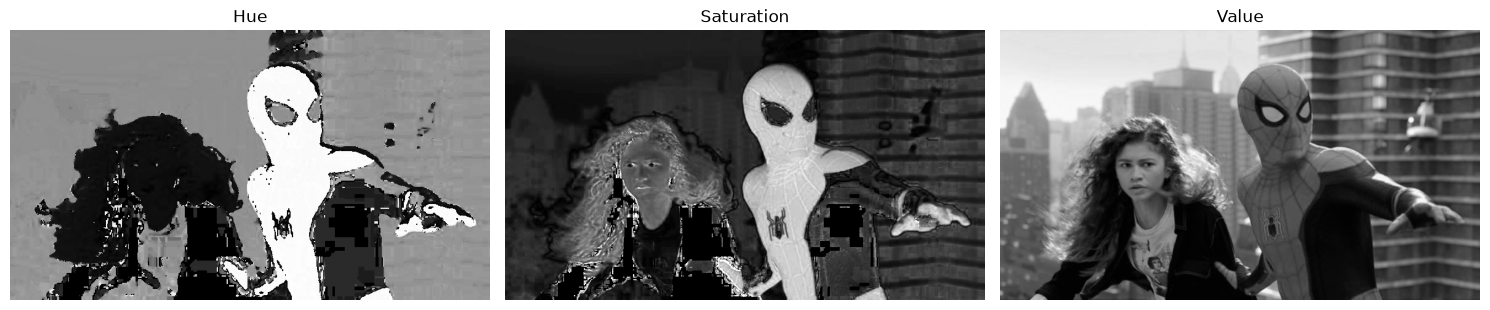

In [82]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

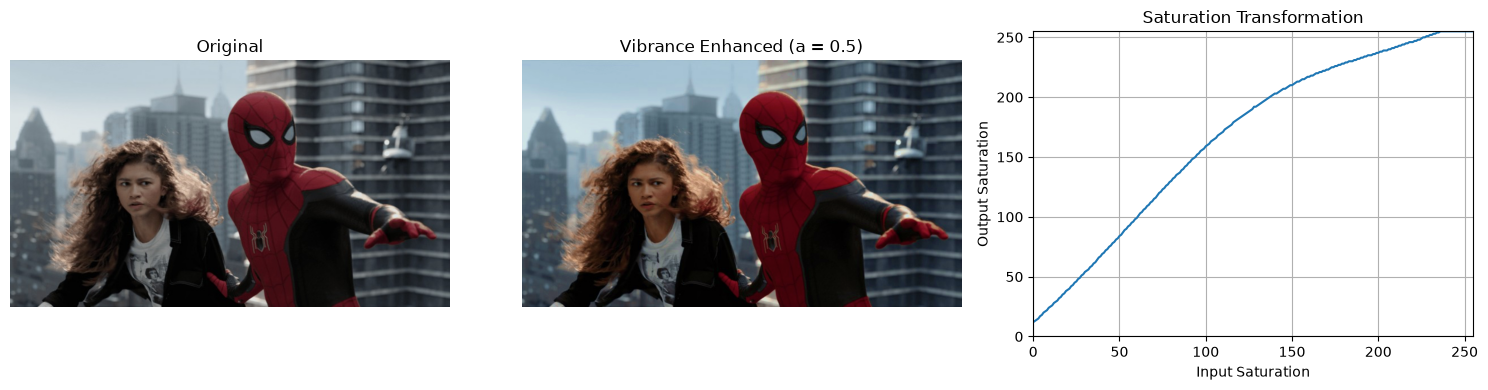

In [83]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(x, transform)
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title("Saturation Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.tight_layout()
plt.show()

The image was converted to HSV and the given nonlinear transformation was applied only to the saturation channel. A value of **a = 0.5** was selected because it increased the saturation of moderately saturated colors while keeping the overall appearance natural.

The hue and value channels were kept unchanged, so the enhancement mainly affected color vividness rather than brightness.

---

## Question 05 - Histogram Equalization From Scratch

### Objective

- Write a custom histogram equalization function.
- Apply it to the image in Fig. 5.
- Show histograms before and after equalization.

### Discussion

- Explain how the histogram and contrast changed after equalization.

In [84]:
def histogram_equalization(im):
    """
    Perform histogram equalization without using cv.equalizeHist().
    Assumes an 8-bit grayscale image.
    """

    # Number of possible gray levels
    L = 256

    # --------------------------------------------------
    # 1. Compute histogram
    # --------------------------------------------------

    hist = np.zeros(L, dtype=np.int64)

    for pixel in im.ravel():
        hist[pixel] += 1


    # --------------------------------------------------
    # 2. Compute cumulative histogram
    # --------------------------------------------------

    cdf = np.cumsum(hist)


    # --------------------------------------------------
    # 3. Create intensity mapping
    # s_k = (L - 1)/(MN) * cumulative_sum
    # --------------------------------------------------

    MN = im.size

    transform = ((L - 1) / MN) * cdf

    transform = np.round(transform).astype(np.uint8)


    # --------------------------------------------------
    # 4. Apply mapping
    # --------------------------------------------------

    equalized = transform[im]

    return equalized, hist, transform

In [86]:
img = cv.imread("images/q5.tif",
                cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Check the image path.")

equalized, hist_original, transform = histogram_equalization(img)

In [87]:
hist_equalized = np.zeros(256, dtype=np.int64)

for pixel in equalized.ravel():
    hist_equalized[pixel] += 1

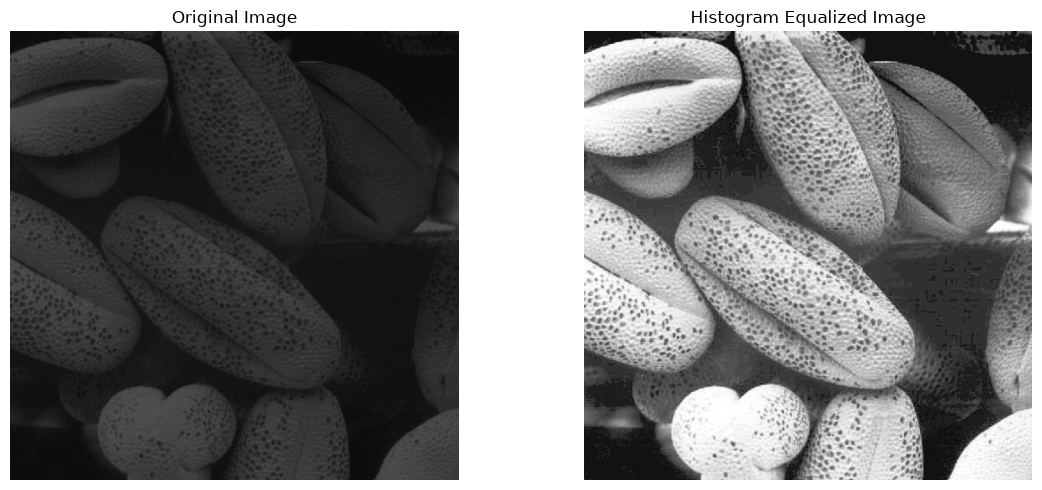

In [88]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

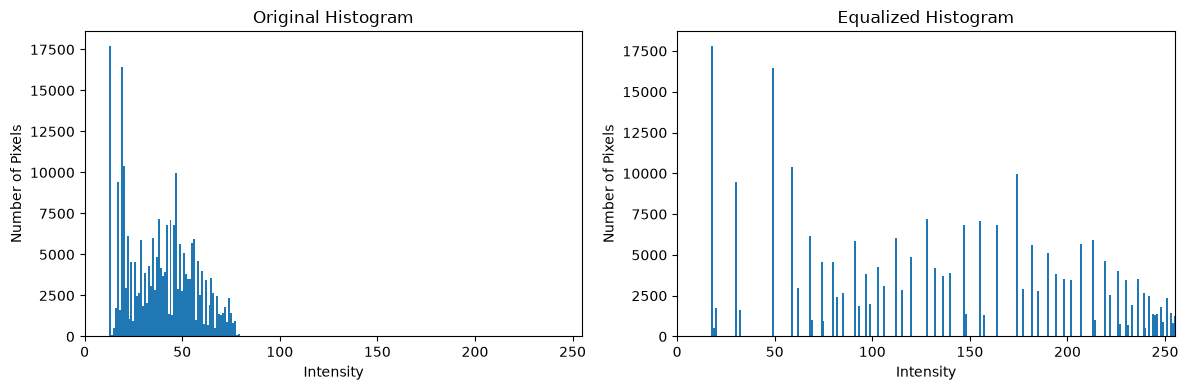

In [89]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(np.arange(256), hist_original, width=1)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0, 255])

plt.subplot(1, 2, 2)
plt.bar(np.arange(256), hist_equalized, width=1)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

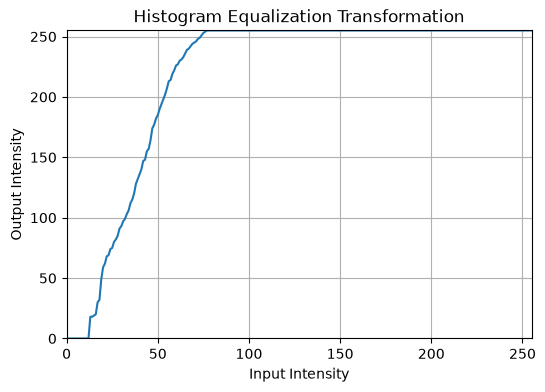

In [90]:
plt.figure(figsize=(6, 4))

plt.plot(np.arange(256), transform)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Histogram Equalization Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.show()

Histogram equalization was implemented using the cumulative distribution of the original image histogram. The original image is dominated by low intensity values and therefore appears dark.

After equalization, the intensities are distributed over a wider dynamic range, increasing the overall contrast and revealing details that were difficult to observe in the original image.

---

## Question 06 - Foreground-Only Histogram Equalization

### Objective

- Split the image into HSV planes and display them in grayscale.
- Extract a foreground mask by thresholding a suitable plane.
- Histogram-equalize only the foreground.
- Recombine the equalized foreground with the background.

### Results To Show

- Hue, saturation, and value planes
- Foreground mask
- Original image
- Image with histogram-equalized foreground

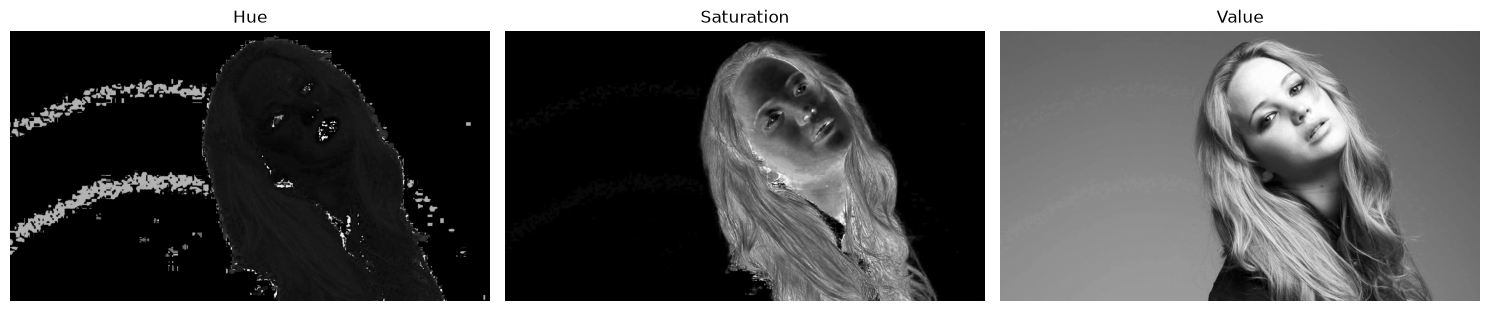

In [95]:
# Load image
# ------------------------------------------------------------

img = cv.imread("images/q6.jpeg")

if img is None:
    raise FileNotFoundError("Check image path.")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# ------------------------------------------------------------
# Convert to HSV and split planes
# ------------------------------------------------------------

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

# Display HSV planes
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

In [102]:
# Create foreground mask using saturation

threshold = 40

_, mask = cv.threshold(
    S,
    threshold,
    255,
    cv.THRESH_BINARY
)

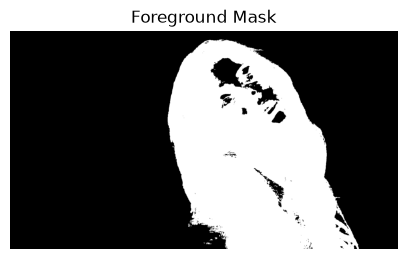

In [97]:
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")
plt.show()

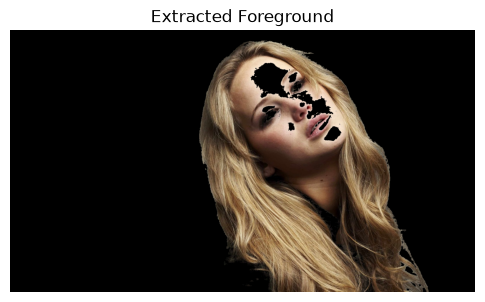

In [103]:
# Extract foreground using the mask

foreground = cv.bitwise_and(
    img,
    img,
    mask=mask
)

foreground_rgb = cv.cvtColor(foreground, cv.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(foreground_rgb)
plt.title("Extracted Foreground")
plt.axis("off")
plt.show()

In [110]:
# Get foreground intensity values from V channel


foreground_values = V[mask == 255]

In [111]:
# Compute foreground histogram manually

hist = np.zeros(256, dtype=np.int64)

for pixel in foreground_values: 
    hist[pixel] += 1

In [112]:
# Compute cumulative histogram

cdf = np.cumsum(hist)

In [113]:
# histogram equalization mapping

L = 256
N = foreground_values.size

transform = ((L - 1) / N) * cdf

transform = np.round(transform).astype(np.uint8)


In [114]:
# Equalize only foreground pixels in V channel

V_equalized = V.copy()

V_equalized[mask == 255] = transform[
    V[mask == 255]
]

In [115]:
# Recombine HSV channels
hsv_equalized = cv.merge([
    H,
    S,
    V_equalized
])

result_bgr = cv.cvtColor(
    hsv_equalized,
    cv.COLOR_HSV2BGR
)

result_rgb = cv.cvtColor(
    result_bgr,
    cv.COLOR_BGR2RGB
)

In [116]:
# Extract background separately

background_mask = cv.bitwise_not(mask)

background = cv.bitwise_and(
    img,
    img,
    mask=background_mask
)

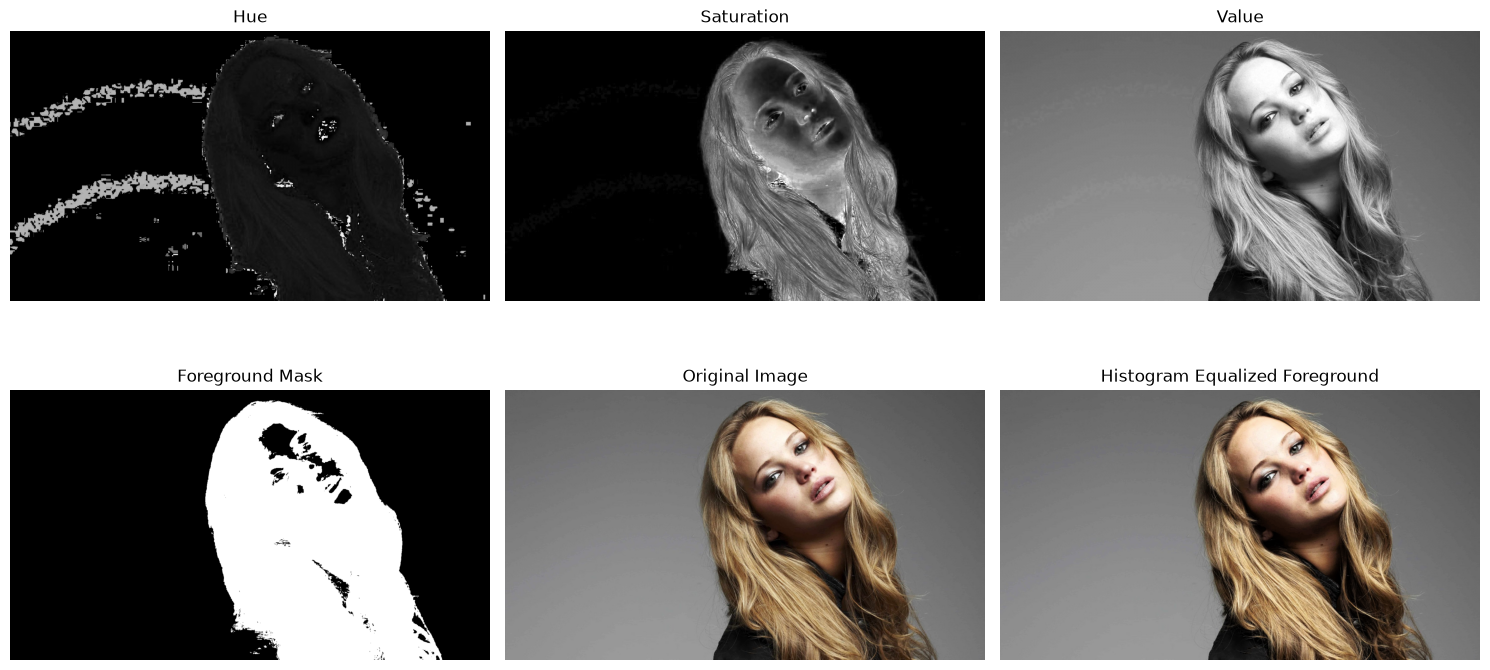

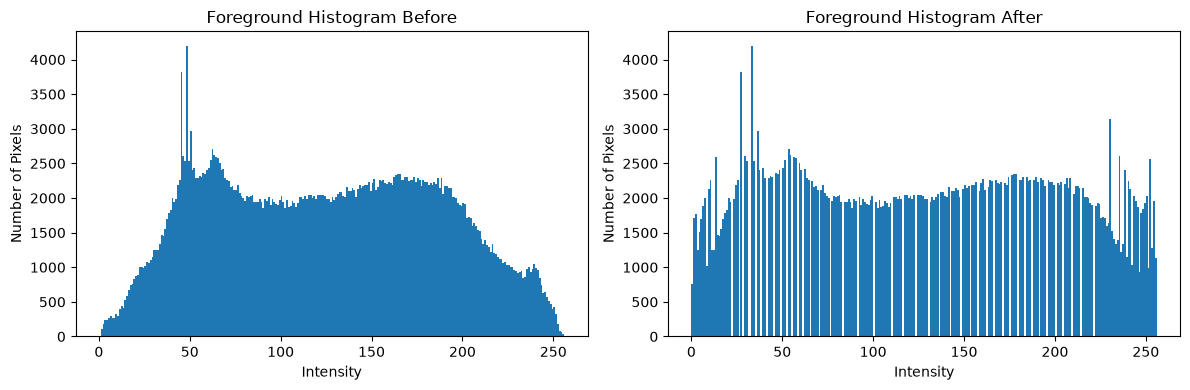

In [117]:
# Final required display

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result_rgb)
plt.title("Histogram Equalized Foreground")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. Optional: histogram before and after equalization
# ------------------------------------------------------------

equalized_foreground_values = V_equalized[mask == 255]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(
    foreground_values,
    bins=256,
    range=[0, 256]
)
plt.title("Foreground Histogram Before")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.hist(
    equalized_foreground_values,
    bins=256,
    range=[0, 256]
)
plt.title("Foreground Histogram After")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()



The image was converted to HSV and the **saturation channel** was thresholded to obtain a binary foreground mask. The mask was then used to extract only the foreground region.

Histogram equalization was applied to the **V (value) channel** of the foreground using its histogram and cumulative distribution. The background pixels were left unchanged.

Finally, the equalized foreground was recombined with the original background to obtain the final image. This improves the contrast of the foreground without altering the background. :contentReference[oaicite:0]{index=0}

---

## Question 07 - Sobel Filtering

### Objective

- Apply Sobel filtering using `cv.filter2D`.
- Write a custom Sobel filtering implementation.
- Use the separable property of the Sobel operator.

### Comparison

- Compare the three Sobel filtering outputs and discuss efficiency.

In [122]:
# Load image

img = cv.imread("images/q7.jpeg", cv.IMREAD_GRAYSCALE)

In [123]:
# Sobel kernel

sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

In [124]:
# (a) Sobel filtering using cv.filter2D

sobel_cv = cv.filter2D(
    img, 
    cv.CV_32F, 
    sobel_x
)

In [125]:
# (b) Own convolution implementation

def convolution2d(im, kernel):
    h, w = im.shape

    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        im,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant"
    )

    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(
                region * kernel
            )

    return output

sobel_manual = convolution2d(
    img.astype(np.float32),
    sobel_x
)


In [126]:
# (c) Separable Sobel filtering

vertical = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

horizontal = np.array([
    [1, 0, -1]
], dtype=np.float32)

# First filter vertically
temp = cv.filter2D(
    img.astype(np.float32),
    cv.CV_32F,
    vertical
)

# Then filter horizontally
sobel_separable = cv.filter2D(
    temp,
    cv.CV_32F,
    horizontal
)

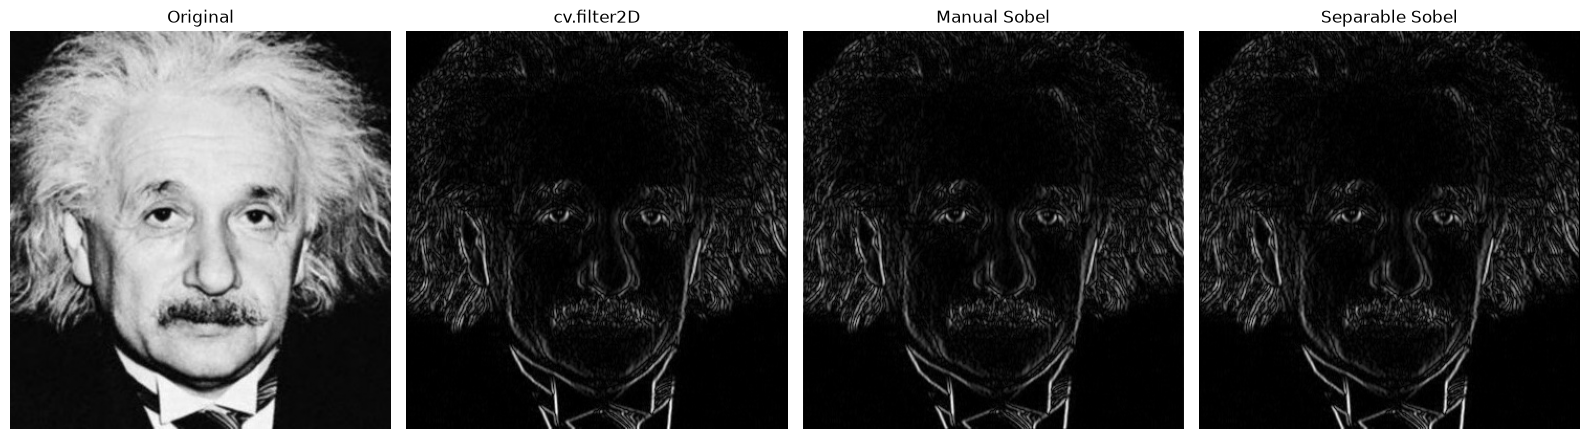

In [127]:
# Display
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(sobel_cv), cmap="gray")
plt.title("cv.filter2D")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(sobel_manual), cmap="gray")
plt.title("Manual Sobel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(np.abs(sobel_separable), cmap="gray")
plt.title("Separable Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()


The Sobel operator was applied to detect horizontal intensity gradients in the image. The result was first obtained using OpenCV's `filter2D`, then reproduced using a manually implemented 2-D convolution.

The Sobel kernel is separable, so it can also be implemented as two 1-D filtering operations: a vertical smoothing filter followed by a horizontal derivative filter. The three approaches should produce nearly identical edge responses.

---

## Question 08 - Image Zooming

### Objective

- Write a zoom function for scale factor `s` in `(0, 10]`.
- Support nearest-neighbor interpolation.
- Support bilinear interpolation.
- Test by scaling small images by a factor of 4.
- Compare with original large images using normalized SSD.

### Results To Show

- Nearest-neighbor zoomed images
- Bilinear zoomed images
- Normalized SSD values

In [25]:
# Question 08 code

---

## Question 09 - Foreground Segmentation and Background Blur

### Objective

- Use grabCut to segment the flower image.
- Show the final segmentation mask, foreground image, and background image.
- Produce an enhanced image with a substantially blurred background.
- Explain why the background near the flower edge appears dark.

### Results To Show

- Segmentation mask
- Foreground image
- Background image
- Original and enhanced images side-by-side

In [26]:
# Question 09 code

---

## Question 10 - Bilateral Filtering

### Objective

- Smooth the Lake Minaret image while keeping edges sharp.
- Apply OpenCV's `bilateralFilter`.
- Implement a custom bilateral filter.
- Compare Gaussian blur, OpenCV bilateral filtering, and custom bilateral filtering.
- Use a quantitative measure to compare the results.

### Parameters

- `sigma_s = `
- `sigma_r = `
- Gaussian kernel size: 
- Quantitative metric: 

In [27]:
# Question 10 code

---

## Conclusion

- Summarize the main observations from all questions.
- Compare the effectiveness of different enhancement and filtering techniques.
- Mention limitations and possible improvements.

## References

- Assignment PDF
- Lecture slides
- OpenCV documentation
- NumPy documentation